In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# --- 1. Rosenbrock Function ---
# f(x,y) = (1-x)^2 + 100(y-x^2)^2
def rosenbrock(params):
    x, y = params[0], params[1]
    return (1 - x)**2 + 100 * (y - x**2)**2

def grad_rosenbrock(params):
    x, y = params[0], params[1]
    # Derivative with respect to x
    dx = -2 * (1 - x) - 400 * x * (y - x**2)
    # Derivative with respect to y
    dy = 200 * (y - x**2)
    return np.array([dx, dy])

# --- 2. Sinusoidal Function ---
# f(x) = sin(1/x)
# Note: As per instructions, we handle x=0 by adding a tiny epsilon
def sin_func(params):
    x = params[0]
    # Avoid division by zero
    if abs(x) < 1e-8:
        x = 1e-8
    return np.sin(1 / x)

def grad_sin_func(params):
    x = params[0]
    if abs(x) < 1e-8:
        x = 1e-8 # Handle singularity
    # Chain rule: derivative of sin(u) is cos(u) * u'
    # u = 1/x -> u' = -1/x^2
    return np.cos(1 / x) * (-1 / (x**2))

In [ ]:
# Base class not strictly necessary but good for structure
class Optimizer:
    def __init__(self, lr=0.01):
        self.lr = lr

# 1. Gradient Descent (Standard)
class GradientDescent(Optimizer):
    def update(self, params, grads):
        # theta = theta - lr * gradient
        return params - self.lr * grads

# 2. SGD with Momentum
class Momentum(Optimizer):
    def __init__(self, lr=0.01, gamma=0.9):
        super().__init__(lr)
        self.gamma = gamma # Momentum factor
        self.velocity = None

    def update(self, params, grads):
        if self.velocity is None:
            self.velocity = np.zeros_like(params)

        # v = gamma * v + lr * gradient
        # Note: Some implementations use v = gamma * v - lr * gradient.
        # We will use the standard addition form and subtract v.
        self.velocity = self.gamma * self.velocity + self.lr * grads
        return params - self.velocity

# 3. Adagrad
class Adagrad(Optimizer):
    def __init__(self, lr=0.01, epsilon=1e-8):
        super().__init__(lr)
        self.epsilon = epsilon
        self.cache = None # Sum of squared gradients

    def update(self, params, grads):
        if self.cache is None:
            self.cache = np.zeros_like(params)

        # cache = cache + gradient^2
        self.cache += grads**2

        # update = - (lr / sqrt(cache + eps)) * gradient
        adjust = self.lr / (np.sqrt(self.cache) + self.epsilon)
        return params - adjust * grads

# 4. RMSprop
class RMSprop(Optimizer):
    def __init__(self, lr=0.01, beta=0.99, epsilon=1e-8):
        super().__init__(lr)
        self.beta = beta
        self.epsilon = epsilon
        self.cache = None

    def update(self, params, grads):
        if self.cache is None:
            self.cache = np.zeros_like(params)

        # cache = beta * cache + (1 - beta) * gradient^2
        self.cache = self.beta * self.cache + (1 - self.beta) * (grads**2)

        # update = - (lr / sqrt(cache + eps)) * gradient
        adjust = self.lr / (np.sqrt(self.cache) + self.epsilon)
        return params - adjust * grads

# 5. Adam
class Adam(Optimizer):
    def __init__(self, lr=0.01, beta1=0.9, beta2=0.999, epsilon=1e-8):
        super().__init__(lr)
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.m = None # First moment (momentum)
        self.v = None # Second moment (RMSprop-like)
        self.t = 0    # Time step for bias correction

    def update(self, params, grads):
        if self.m is None:
            self.m = np.zeros_like(params)
            self.v = np.zeros_like(params)

        self.t += 1

        # 1. Update biased first moment estimate
        self.m = self.beta1 * self.m + (1 - self.beta1) * grads

        # 2. Update biased second raw moment estimate
        self.v = self.beta2 * self.v + (1 - self.beta2) * (grads**2)

        # 3. Compute bias-corrected first moment estimate
        m_hat = self.m / (1 - self.beta1**self.t)

        # 4. Compute bias-corrected second raw moment estimate
        v_hat = self.v / (1 - self.beta2**self.t)

        # 5. Update parameters
        return params - (self.lr / (np.sqrt(v_hat) + self.epsilon)) * m_hat

--- Task 1a: Rosenbrock Function Optimization ---
Running Gradient Descent with LR=0.01...
  ! Diverged at step 3
Running Momentum with LR=0.01...
  ! Diverged at step 3
Running Adagrad with LR=0.01...
Running RMSprop with LR=0.01...
Running Adam with LR=0.01...
Running Gradient Descent with LR=0.05...
  ! Diverged at step 3
Running Momentum with LR=0.05...
  ! Diverged at step 3
Running Adagrad with LR=0.05...
Running RMSprop with LR=0.05...
Running Adam with LR=0.05...
Running Gradient Descent with LR=0.1...
  ! Diverged at step 3
Running Momentum with LR=0.1...
  ! Diverged at step 3
Running Adagrad with LR=0.1...
Running RMSprop with LR=0.1...
Running Adam with LR=0.1...


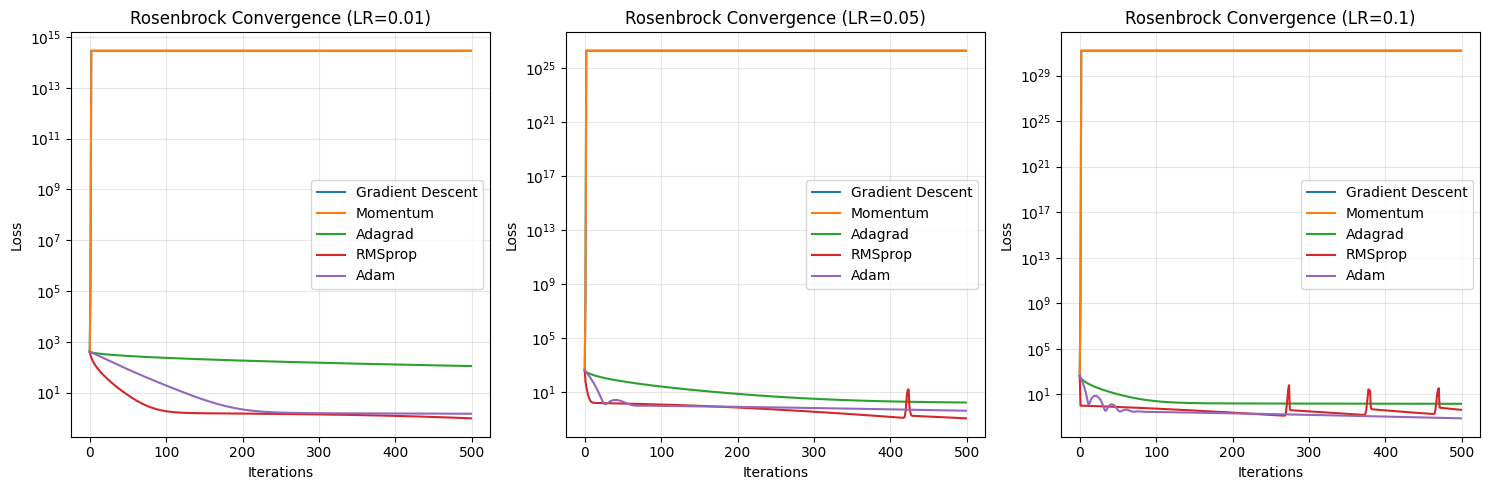


--- Task 1b: Sinusoidal Function Optimization ---


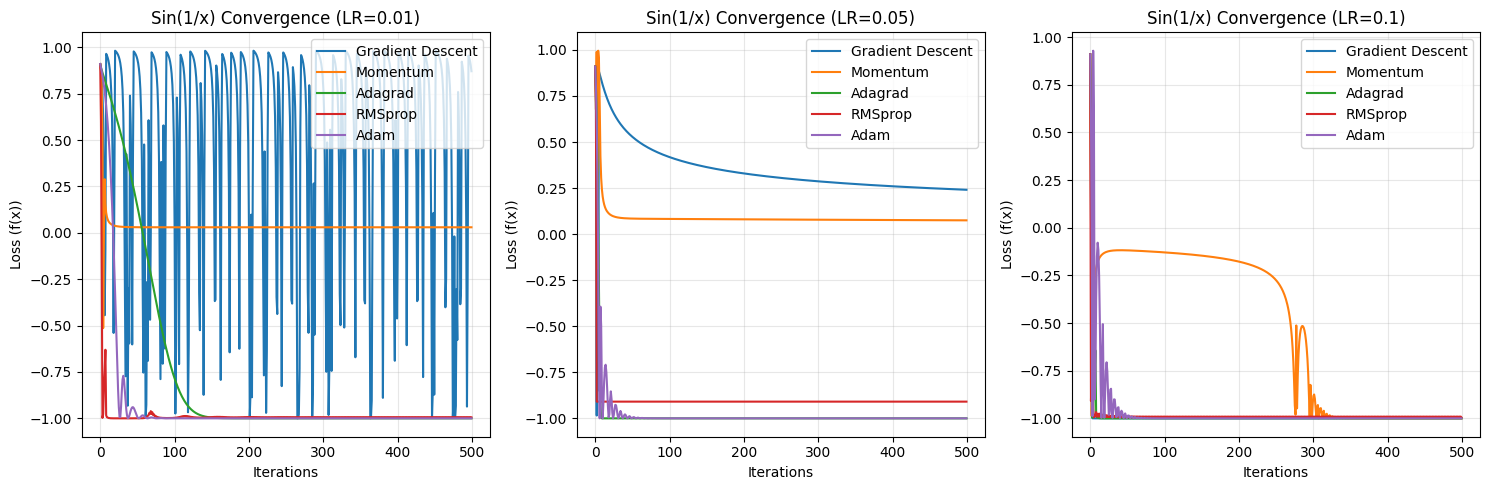

In [ ]:
# --- Helper Function to Run One Experiment ---
def run_optimization(optimizer_class, grad_func, loss_func, start_params, lr, iterations=1000, **kwargs):
    # Initialize the optimizer
    opt = optimizer_class(lr=lr, **kwargs)

    params = np.array(start_params, dtype=np.float64)
    history_loss = []

    for i in range(iterations):
        # 1. Safety Check: Stop if values exploded to Infinity or NaN
        if np.any(np.isnan(params)) or np.any(np.isinf(params)) or np.any(np.abs(params) > 1e9):
            # Fill the rest with the last valid value to keep array length consistent for plotting
            remaining = iterations - len(history_loss)
            history_loss.extend([history_loss[-1]] * remaining)
            print(f"  ! Diverged at step {i}")
            break

        # 2. Calculate Loss and Gradient
        try:
            loss = loss_func(params)
            grads = grad_func(params)
        except RuntimeWarning:
            # Catch math errors inside the function itself
            print(f"  ! Math error at step {i}")
            break

        # 3. Store history
        history_loss.append(loss)

        # 4. Update parameters
        params = opt.update(params, grads)

    return np.array(history_loss)

# --- Main Execution ---

# Configuration
learning_rates = [0.01, 0.05, 0.1]
iterations = 500
start_rosen = [-1.0, -1.0] # Starting point for Rosenbrock
start_sin = [0.5]          # Starting point for Sin(1/x)

optimizers = {
    "Gradient Descent": GradientDescent,
    "Momentum": Momentum,
    "Adagrad": Adagrad,
    "RMSprop": RMSprop,
    "Adam": Adam
}

# --- Experiment 1: Rosenbrock Function ---
print("--- Task 1a: Rosenbrock Function Optimization ---")
plt.figure(figsize=(15, 5))

for i, lr in enumerate(learning_rates):
    plt.subplot(1, 3, i+1)
    plt.title(f"Rosenbrock Convergence (LR={lr})")

    for name, opt_class in optimizers.items():
        print(f"Running {name} with LR={lr}...")
        losses = run_optimization(
            opt_class, grad_rosenbrock, rosenbrock, start_rosen, lr, iterations
        )

        # Only plot if we have valid data
        if len(losses) > 0:
            plt.plot(losses, label=name)

    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.yscale("log") # Log scale helps visualize convergence better
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Experiment 2: Sinusoidal Function ---
print("\n--- Task 1b: Sinusoidal Function Optimization ---")
plt.figure(figsize=(15, 5))

for i, lr in enumerate(learning_rates):
    plt.subplot(1, 3, i+1)
    plt.title(f"Sin(1/x) Convergence (LR={lr})")

    for name, opt_class in optimizers.items():
        # Reset seed or start point if needed, but here we use fixed start
        losses = run_optimization(
            opt_class, grad_sin_func, sin_func, start_sin, lr, iterations
        )
        plt.plot(losses, label=f"{name}")

    plt.xlabel("Iterations")
    plt.ylabel("Loss (f(x))")
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Generating 15 graphs for Rosenbrock Function...
  ! Diverged at step 3
  ! Diverged at step 3
  ! Diverged at step 3
  ! Diverged at step 3
  ! Diverged at step 3
  ! Diverged at step 3


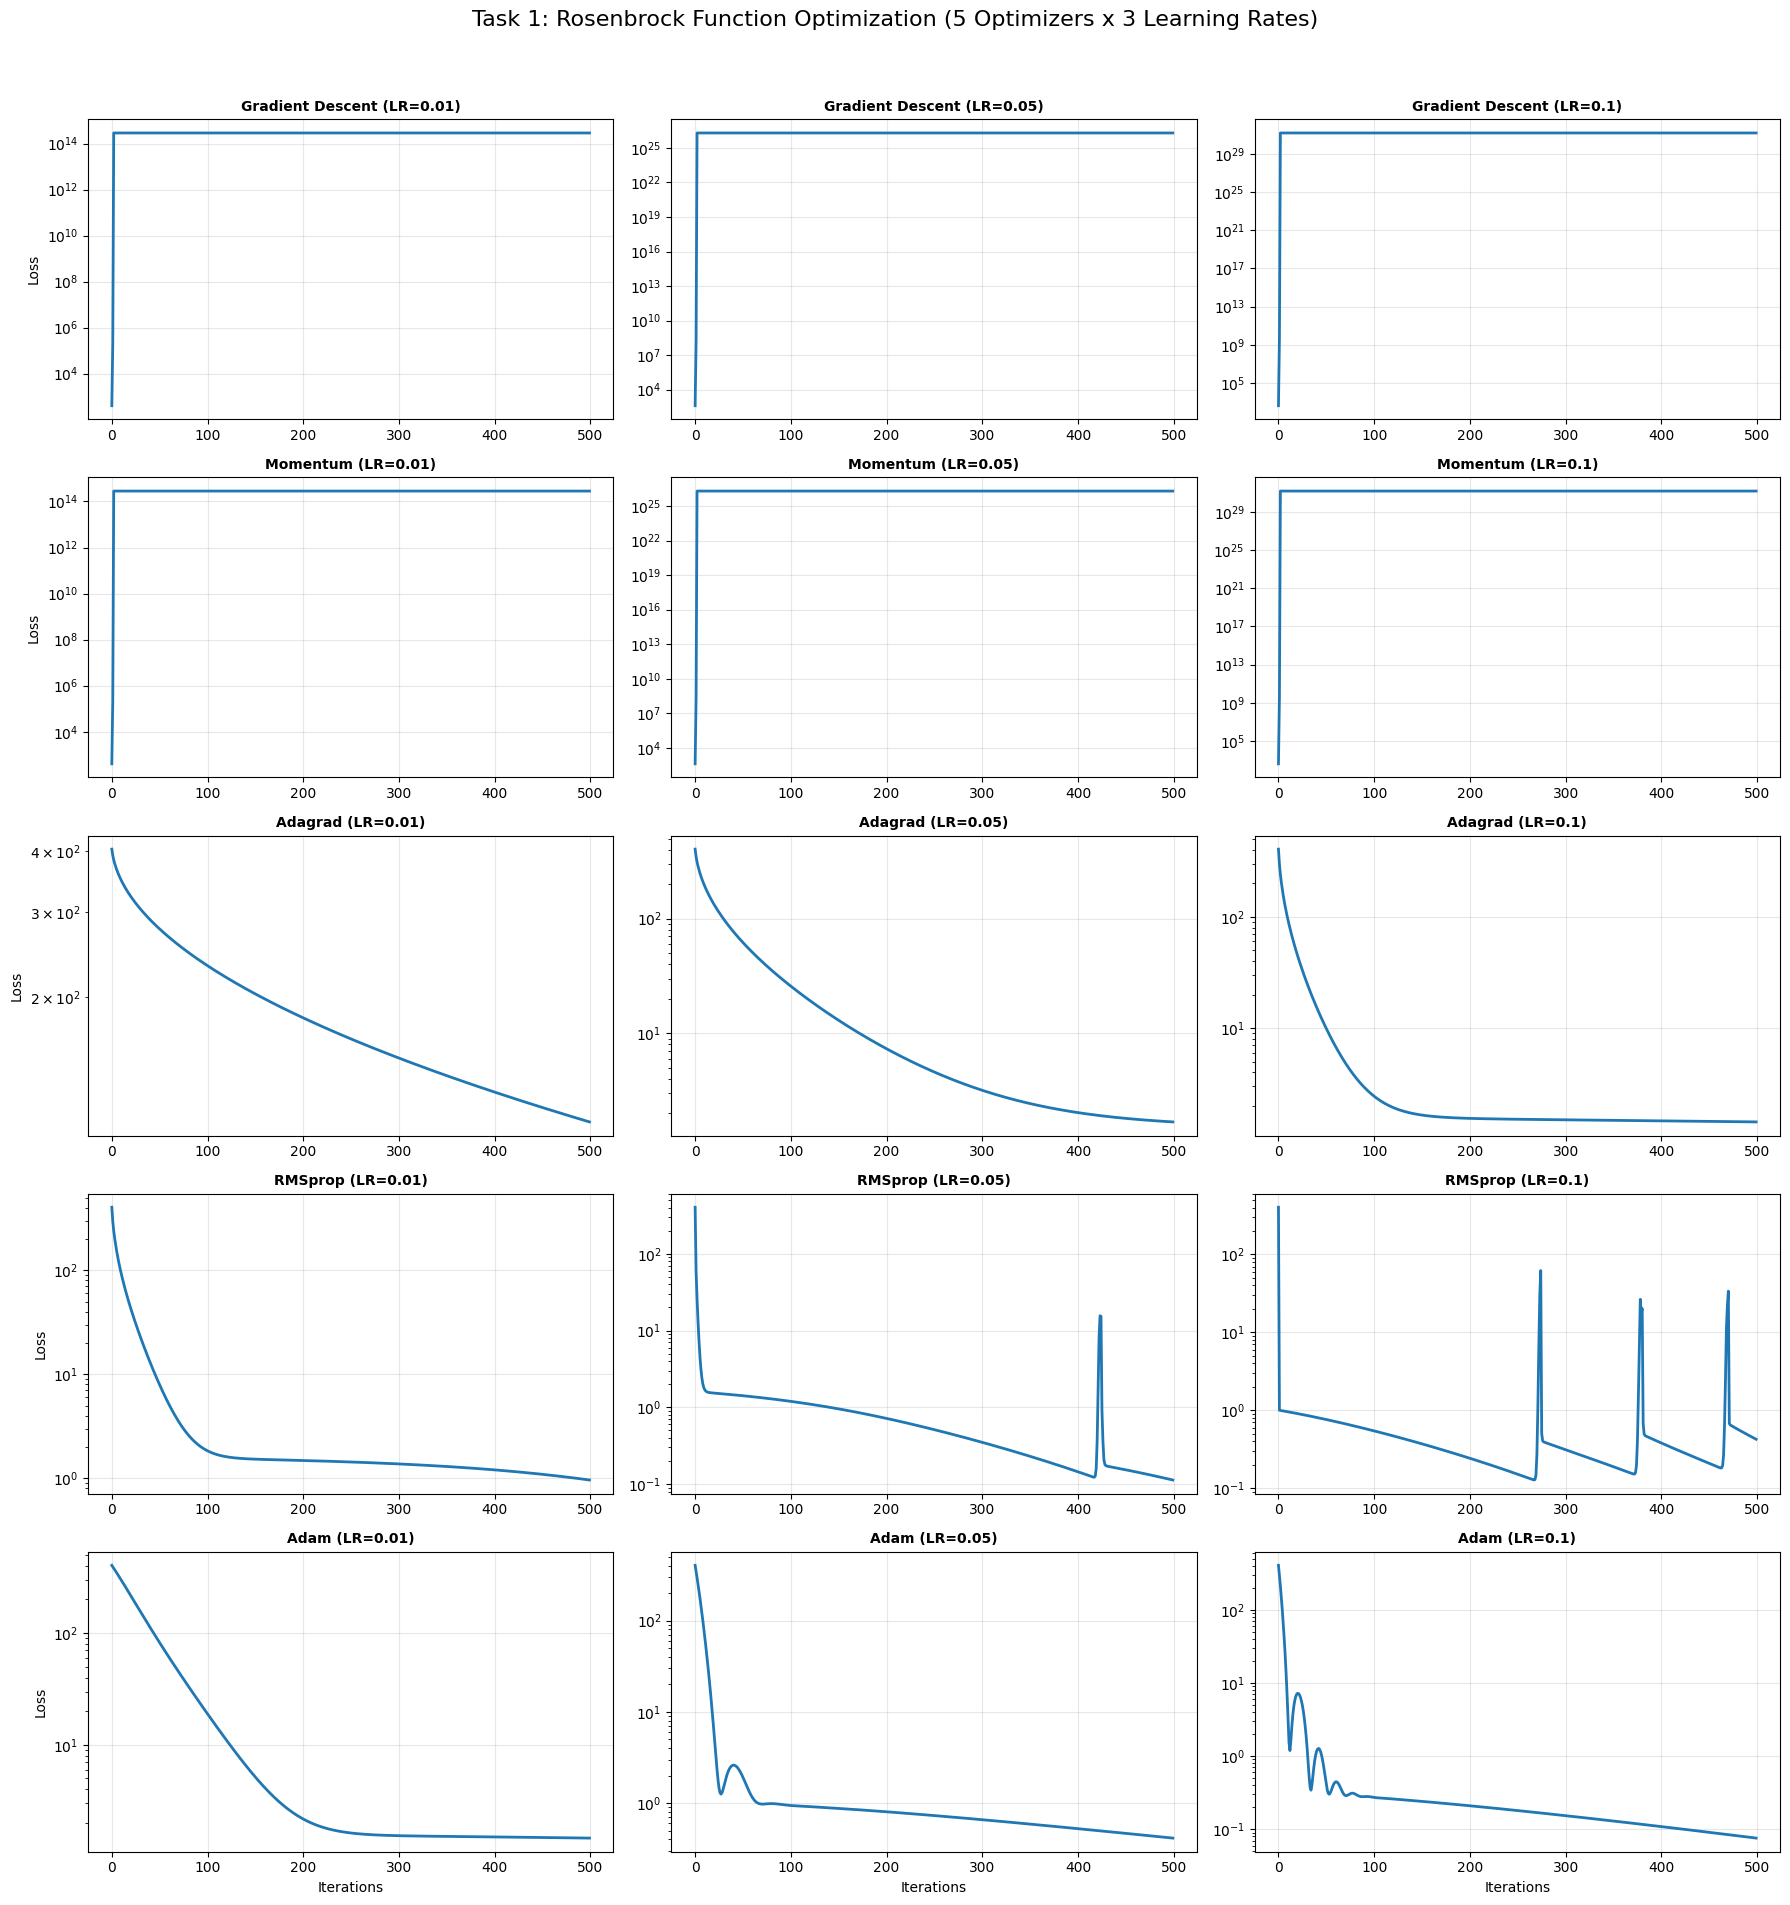


Generating 15 graphs for Sinusoidal Function...


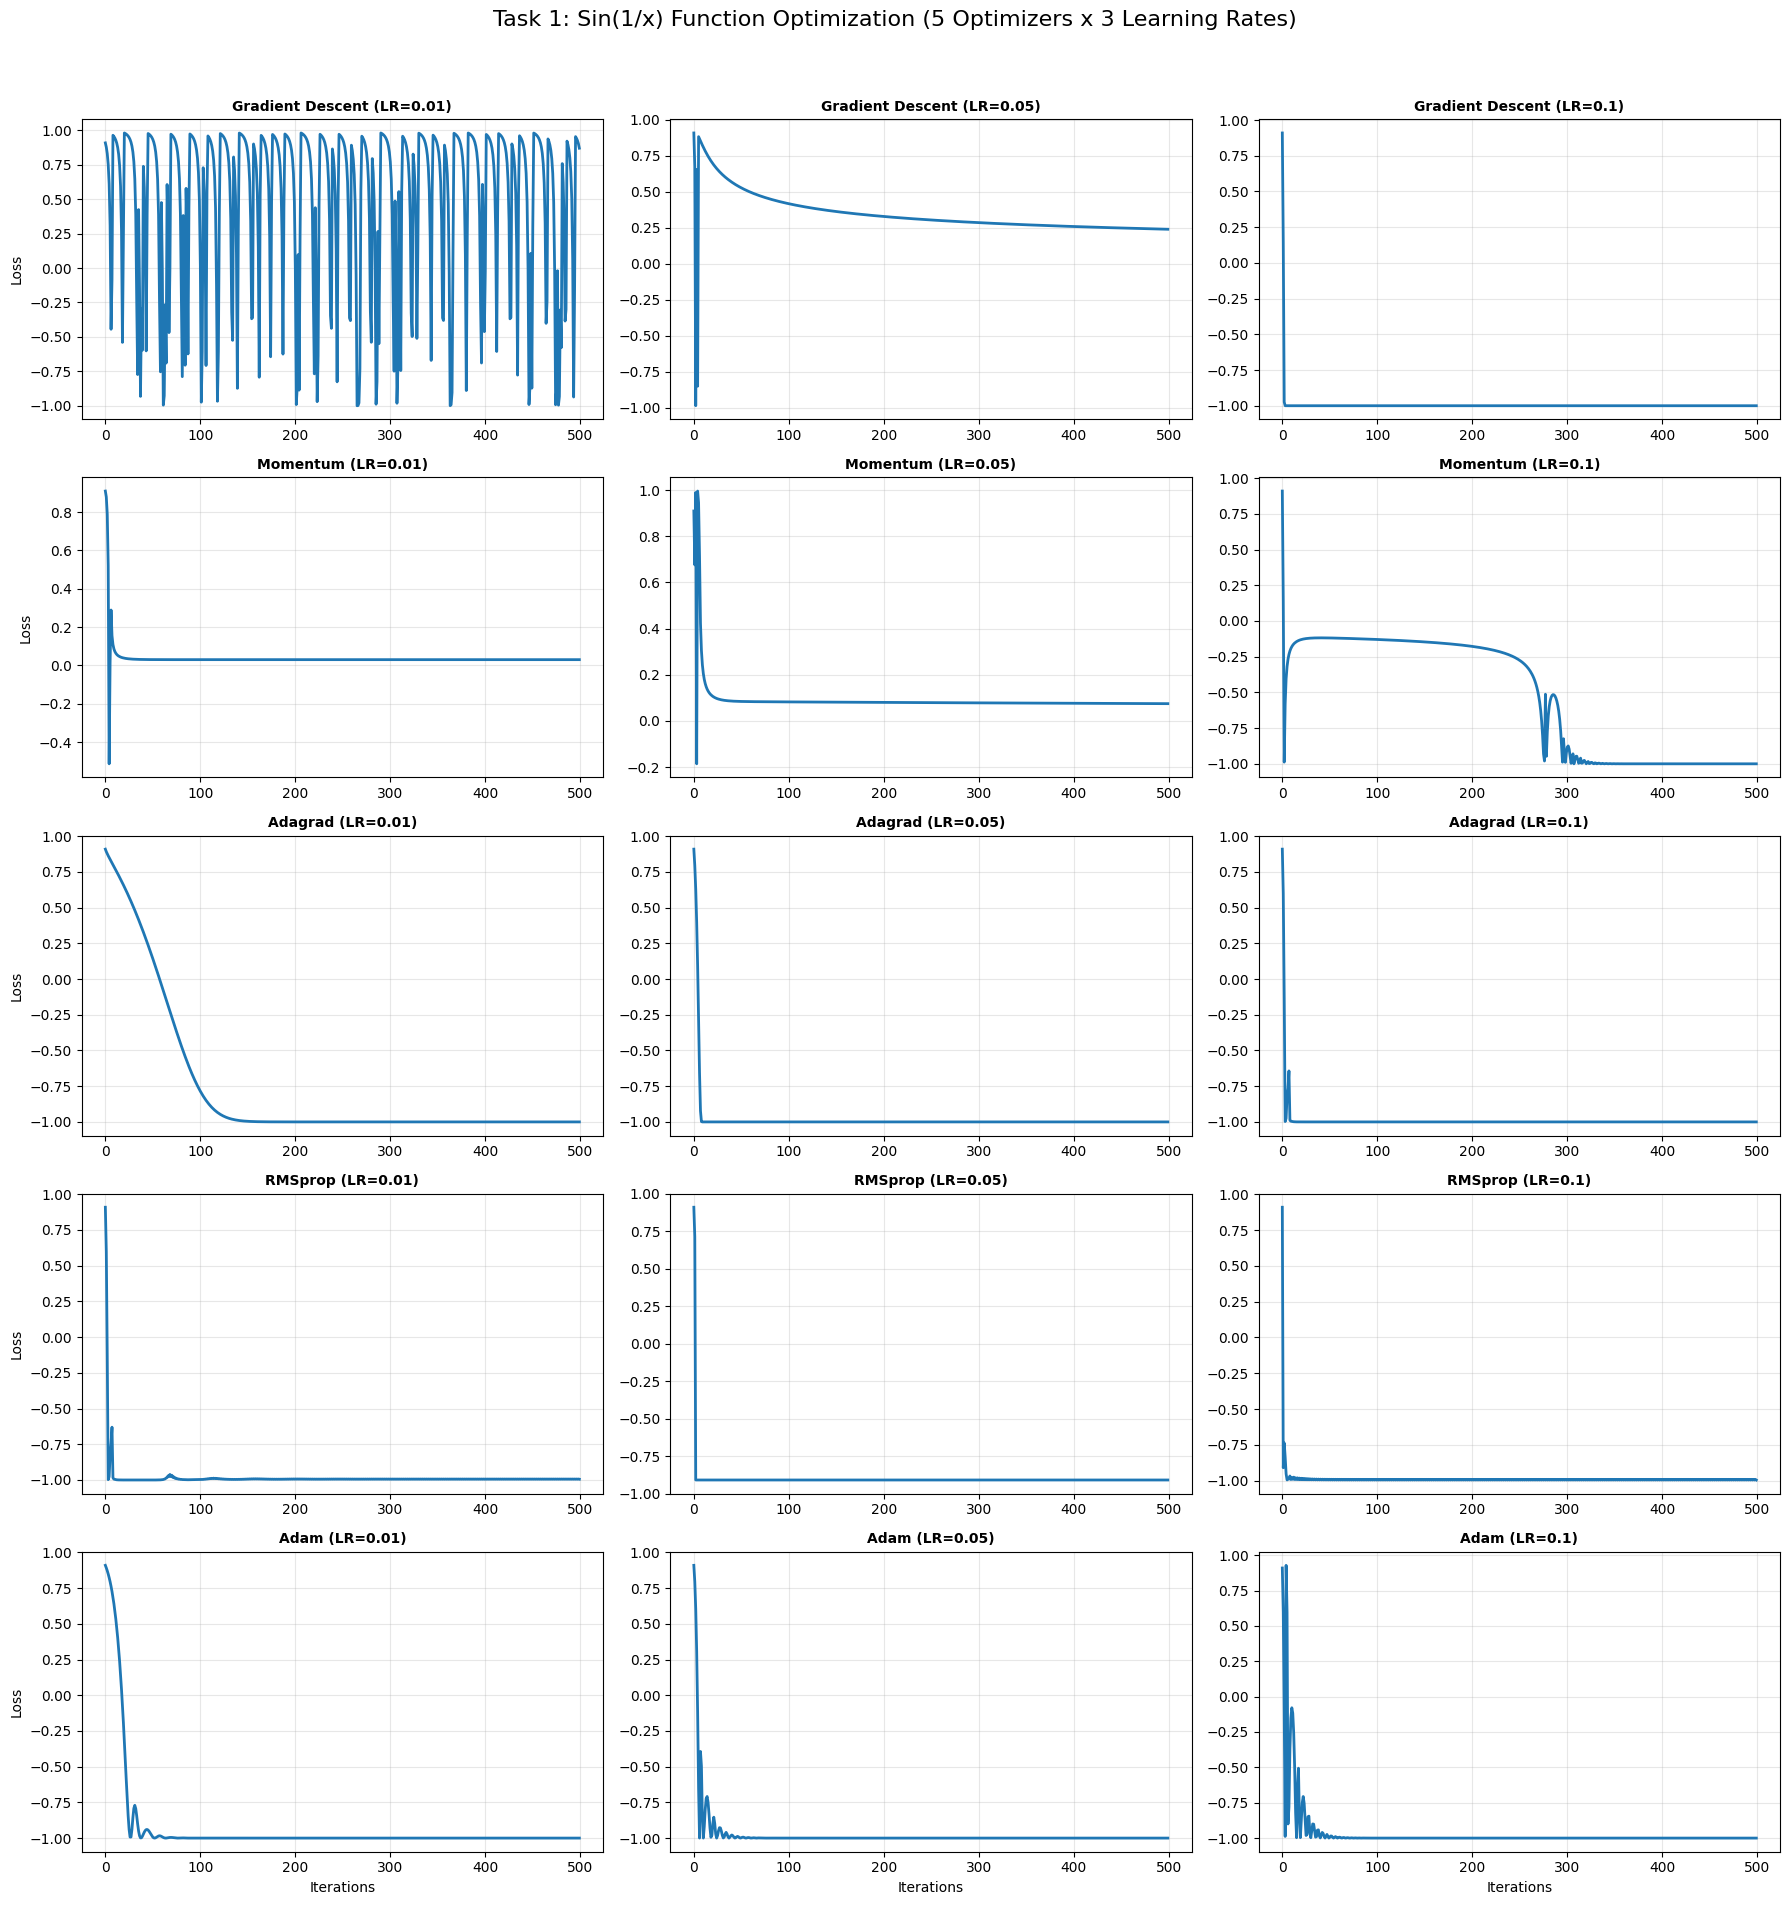

In [ ]:
# Configuration
learning_rates = [0.01, 0.05, 0.1]
iterations = 500
optimizers_list = [
    ("Gradient Descent", GradientDescent),
    ("Momentum", Momentum),
    ("Adagrad", Adagrad),
    ("RMSprop", RMSprop),
    ("Adam", Adam)
]

# --- Helper to plot a 5x3 Grid ---
def plot_grid(function_name, grad_func, loss_func, start_params, y_log_scale=False):
    fig, axes = plt.subplots(5, 3, figsize=(18, 20))
    fig.suptitle(f"Task 1: {function_name} Optimization (5 Optimizers x 3 Learning Rates)", fontsize=16)

    # Loop through Optimizers (Rows)
    for row_idx, (opt_name, opt_class) in enumerate(optimizers_list):

        # Loop through Learning Rates (Columns)
        for col_idx, lr in enumerate(learning_rates):
            ax = axes[row_idx, col_idx]

            # Run Optimization
            # Note: We re-use the safety-checked run_optimization function from before
            losses = run_optimization(
                opt_class, grad_func, loss_func, start_params, lr, iterations
            )

            # Plotting
            if len(losses) > 0:
                ax.plot(losses, color='tab:blue', linewidth=2)

            # Styling
            ax.set_title(f"{opt_name} (LR={lr})", fontsize=10, fontweight='bold')
            if row_idx == 4: # Only label x-axis on bottom row
                ax.set_xlabel("Iterations")
            if col_idx == 0: # Only label y-axis on first column
                ax.set_ylabel("Loss")

            ax.grid(True, alpha=0.3)

            # Log scale for Rosenbrock helps see the drop, linear for Sin
            if y_log_scale:
                ax.set_yscale('log')

    plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Make room for suptitle
    plt.show()

# --- Generate the 15 Graphs for Rosenbrock ---
print("Generating 15 graphs for Rosenbrock Function...")
plot_grid(
    "Rosenbrock Function",
    grad_rosenbrock,
    rosenbrock,
    [-1.0, -1.0],
    y_log_scale=True
)

# --- Generate the 15 Graphs for Sinusoidal ---
print("\nGenerating 15 graphs for Sinusoidal Function...")
plot_grid(
    "Sin(1/x) Function",
    grad_sin_func,
    sin_func,
    [0.5],
    y_log_scale=False
)